
FIRST 5 ROWS
                         Data  Temperatura  Humidade
0  06/01/2023 19:00:00 -03:00         27.2      82.6
1  06/01/2023 20:00:00 -03:00         27.0      83.0
2  06/01/2023 21:00:00 -03:00         27.0      83.0
3  06/01/2023 22:00:00 -03:00         26.7      83.9
4  06/01/2023 23:00:00 -03:00         26.5      85.4


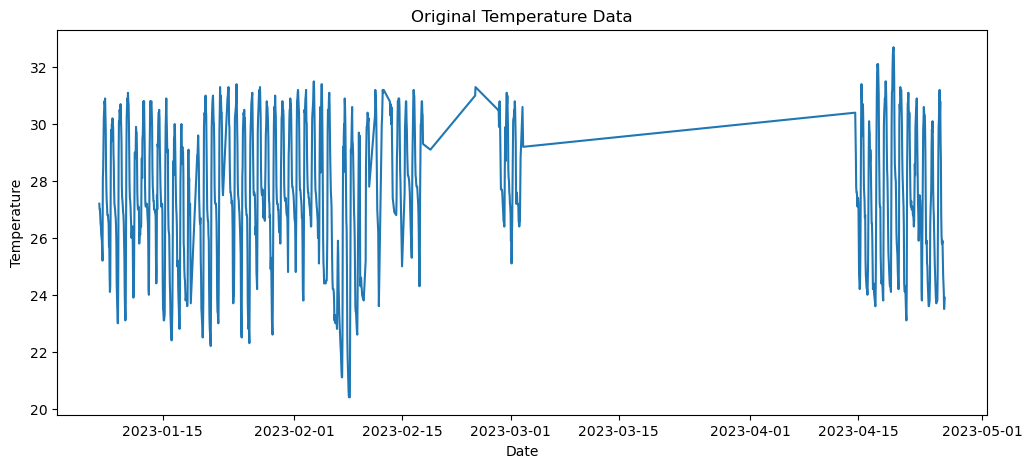


ADF TEST RESULT
----------------------
ADF Statistic : -3.5168993835166282
p-value       : 0.007563542177850737
Data is Stationary


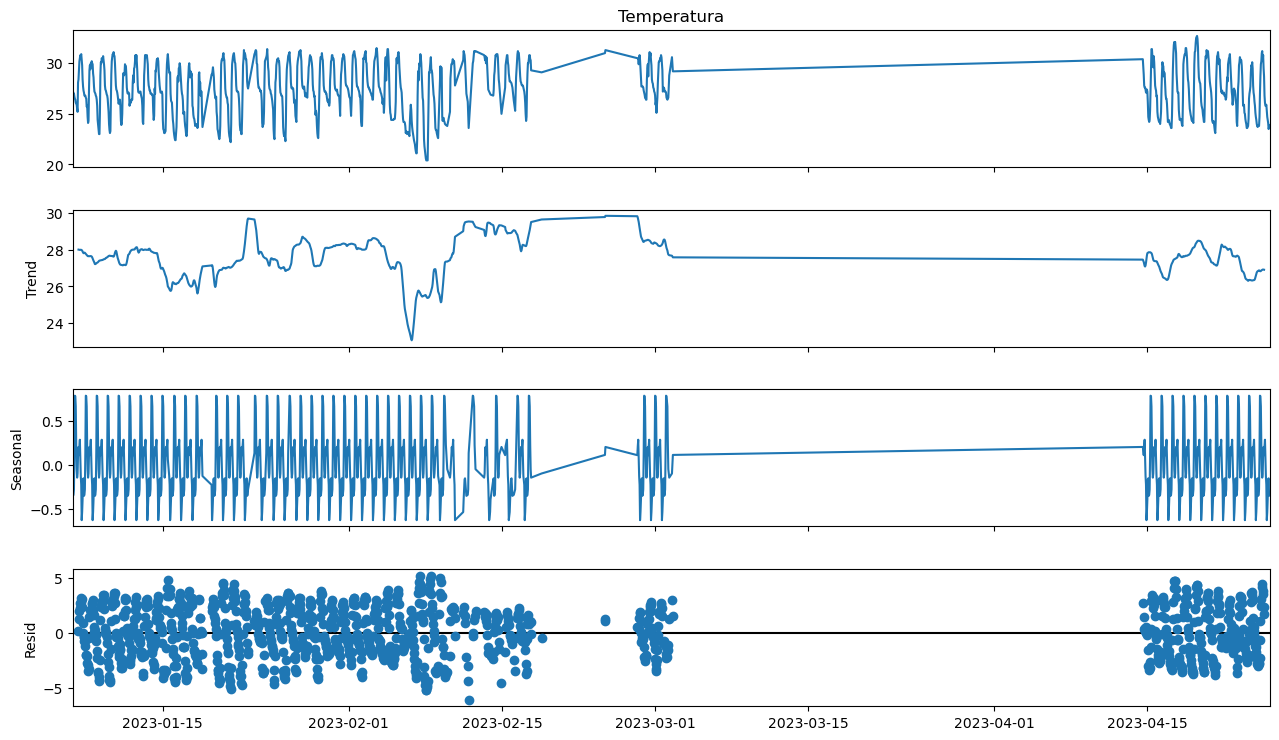

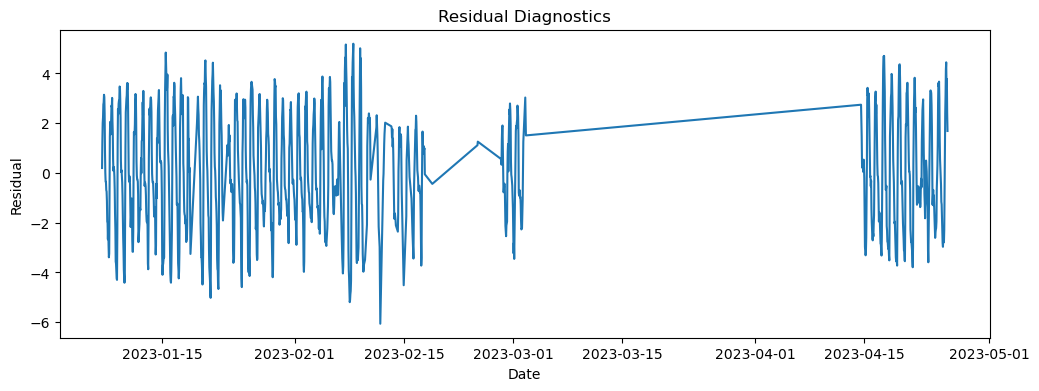

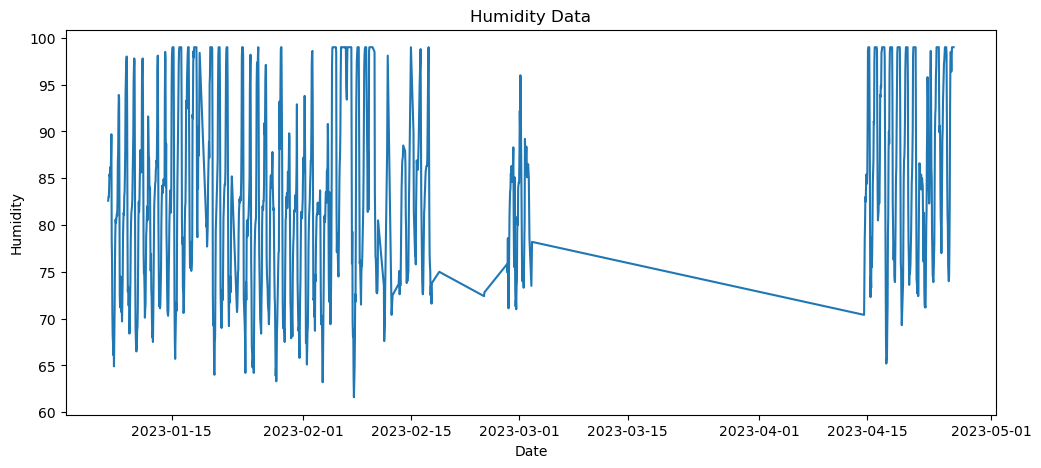


PRACTICAL COMPLETED SUCCESSFULLY


In [3]:

# PR_23 - Modular Analytical Workflow
# Real Aquaculture Dataset

'''
Trend graph shows long-term direction
Seasonal graph shows repeating cycles
Residual graph shows remaining noise

'''
#  IMPORT LIBRARIES 
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# STEP 1: LOAD DATASET 

df = pd.read_csv("B2K weather station.csv")

# Display first rows
print("\nFIRST 5 ROWS")
print(df.head())

# STEP 2: CONVERT DATETIME

# Convert Data column into datetime
df['Data'] = pd.to_datetime(
    df['Data'],
    dayfirst=True,
    errors='coerce'
)

# Remove invalid dates
df = df.dropna(subset=['Data'])

# Set datetime as index
df.set_index('Data', inplace=True)

# STEP 3: SELECT REQUIRED COLUMNS

# Keep only required columns
df = df[['Temperatura', 'Humidade']]

# STEP 4: HANDLE MISSING VALUES 

# Fill missing values
df['Temperatura'] = df['Temperatura'].interpolate()

df['Humidade'] = df['Humidade'].interpolate()

# STEP 5: ORIGINAL TEMPERATURE GRAPH 

plt.figure(figsize=(12,5))

plt.plot(df['Temperatura'])

plt.title("Original Temperature Data")
plt.xlabel("Date")
plt.ylabel("Temperature")

plt.show()

# STEP 6: ADF TEST 

adf_result = adfuller(df['Temperatura'])

print("\nADF TEST RESULT")
print("----------------------")

print("ADF Statistic :", adf_result[0])
print("p-value       :", adf_result[1])

if adf_result[1] <= 0.05:
    print("Data is Stationary")
else:
    print("Data is Non-Stationary")

# STEP 7: DECOMPOSITION 

decomposition = seasonal_decompose(
    df['Temperatura'],
    model='additive',
    period=24
)

# Plot decomposition
decomposition.plot()

plt.gcf().set_size_inches(14,8)

plt.show()

# STEP 8: RESIDUAL DIAGNOSTICS 

residual = decomposition.resid

plt.figure(figsize=(12,4))

plt.plot(residual)

plt.title("Residual Diagnostics")
plt.xlabel("Date")
plt.ylabel("Residual")

plt.show()

# STEP 9: HUMIDITY GRAPH 

plt.figure(figsize=(12,5))

plt.plot(df['Humidade'])

plt.title("Humidity Data")
plt.xlabel("Date")
plt.ylabel("Humidity")

plt.show()



print("\nPRACTICAL COMPLETED SUCCESSFULLY")